In [1]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import seaborn as sns
from astropy.io import fits
from matplotlib import pyplot as plt

#from pipeline_config import MAPS_DIR

In [2]:
datasets = [
     {
        "instrument": "MUSE",
        "bin": 0,
        "line": "[Ar III]",
        "filename": "MUSE-M42-Ar-bin0-ivsv.fits",
        "label": r"$1\times1$",
    },
     {
        "instrument": "MUSE",
        "bin": 1,
        "line": "[Ar III]",
        "filename": "MUSE-M42-Ar-bin1-ivsv.fits",
        "label": r"$2 \times 2$",
    },
     {
        "instrument": "MUSE",
        "bin": 2,
        "line": "[Ar III]",
        "filename": "MUSE-M42-Ar-bin2-ivsv.fits",
        "label": r"$4 \times 4$",
    },
     {
        "instrument": "MUSE",
        "bin": 3,
        "line": "[Ar III]",
        "filename": "MUSE-M42-Ar-bin3-ivsv.fits",
        "label": r"$8 \times 8$",
    },
     {
        "instrument": "MUSE",
        "bin": 4,
        "line": "[Ar III]",
        "filename": "MUSE-M42-Ar-bin4-ivsv.fits",
        "label": r"$16 \times 16$",
    },
     {
        "instrument": "MUSE",
        "bin": 5,
        "line": "[Ar III]",
        "filename": "MUSE-M42-Ar-bin5-ivsv.fits",
        "label": r"$64 \times 64$",
    },
]

In [3]:
def load_velocity_dataset(entry):
    fits_path = entry["filename"]

    with fits.open(fits_path) as hdul:
        sb = hdul["MOM0"].data.astype(float)
        vv = hdul["MOM1"].data.astype(float)
#        mask = hdul["MASK"].data.astype(bool)

    #sb = np.where(mask, sb, np.nan)
    #vv = np.where(mask, vv, np.nan)

    df = pd.DataFrame({
        "X": np.indices(vv.shape)[0].ravel(),
        "Y": np.indices(vv.shape)[1].ravel(),
        "VV": vv.ravel(),
        "SB": sb.ravel(),
#        "mask": mask.ravel(),
    })

    df = df.dropna(subset=["VV"])

    df["instrument"] = entry["instrument"]
    df["line"] = entry["line"]
    df["label"] = entry["label"]
    df["filename"] = entry["filename"]
    df["bin"] = entry["bin"]

    mean_v = df["VV"].mean()
    df["RV_centered"] = df["VV"] - mean_v

    raw = {
        "sb": sb,
        "vv": vv,
#        "mask": mask,
        "instrument": entry["instrument"],
        "line": entry["line"],
        "label": entry["label"],
        "filename": entry["filename"],
    }

    return df, raw

In [4]:
processed_list = []
raw_data = {}

for entry in datasets:
    df, raw = load_velocity_dataset(entry)
    processed_list.append(df)

    key = (entry["line"], entry["instrument"])
    raw_data[key] = raw

processed_data = pd.concat(processed_list, ignore_index=True)

In [5]:
processed_data.head()

,X,Y,VV,SB,instrument,line,label,filename,bin,RV_centered
0,0,586,31.628904,76601.921875,MUSE,[Ar III],$1\times1$,MUSE-M42-Ar-bin0-ivsv.fits,0,1.413855
1,0,587,28.954547,77175.234375,MUSE,[Ar III],$1\times1$,MUSE-M42-Ar-bin0-ivsv.fits,0,-1.260502
2,0,589,23.375149,88722.992188,MUSE,[Ar III],$1\times1$,MUSE-M42-Ar-bin0-ivsv.fits,0,-6.839900
3,0,590,39.474470,80306.671875,MUSE,[Ar III],$1\times1$,MUSE-M42-Ar-bin0-ivsv.fits,0,9.259421
4,0,591,38.874033,80236.671875,MUSE,[Ar III],$1\times1$,MUSE-M42-Ar-bin0-ivsv.fits,0,8.658984


In [6]:
processed_data.groupby(["bin"])["VV"].describe()

,count,mean,std,min,25%,50%,75%,max
bin,,,,,,,,
0,2570454.0,30.215049,5.473892,-1591.335120,27.742495,30.270732,32.739985,880.961737
1,641632.0,30.200433,3.810058,-256.873365,28.158890,30.228907,32.329438,241.189561
2,160168.0,30.199200,3.221635,-20.304991,28.397858,30.195681,32.139551,135.166164
3,39871.0,30.199796,3.020064,-60.227556,28.510924,30.179217,32.089109,47.788150
4,9781.0,30.221712,2.846164,-5.406387,28.563767,30.215370,32.039800,39.561939
5,2346.0,30.261038,2.660661,14.162860,28.557650,30.244832,32.056718,38.875913


In [7]:
processed_data

,X,Y,VV,SB,instrument,line,label,filename,bin,RV_centered
0,0,586,31.628904,76601.921875,MUSE,[Ar III],$1\times1$,MUSE-M42-Ar-bin0-ivsv.fits,0,1.413855
1,0,587,28.954547,77175.234375,MUSE,[Ar III],$1\times1$,MUSE-M42-Ar-bin0-ivsv.fits,0,-1.260502
2,0,589,23.375149,88722.992188,MUSE,[Ar III],$1\times1$,MUSE-M42-Ar-bin0-ivsv.fits,0,-6.839900
3,0,590,39.474470,80306.671875,MUSE,[Ar III],$1\times1$,MUSE-M42-Ar-bin0-ivsv.fits,0,9.259421
4,0,591,38.874033,80236.671875,MUSE,[Ar III],$1\times1$,MUSE-M42-Ar-bin0-ivsv.fits,0,8.658984
...,...,...,...,...,...,...,...,...,...,...
3424247,44,49,28.943341,99137.322533,MUSE,[Ar III],$64 \times 64$,MUSE-M42-Ar-bin5-ivsv.fits,5,-1.317697
3424248,44,50,29.482753,96551.983559,MUSE,[Ar III],$64 \times 64$,MUSE-M42-Ar-bin5-ivsv.fits,5,-0.778284
3424249,44,51,29.805880,80141.893105,MUSE,[Ar III],$64 \times 64$,MUSE-M42-Ar-bin5-ivsv.fits,5,-0.455158
3424250,44,52,29.808742,70084.501293,MUSE,[Ar III],$64 \times 64$,MUSE-M42-Ar-bin5-ivsv.fits,5,-0.452295


In [8]:
ha_muse_bin0 = processed_data[
    (processed_data["filename"] == "MUSE-M42-Ar-bin0-ivsv.fits")
]

ha_muse_bin1 = processed_data[
    (processed_data["filename"] == "MUSE-M42-Ar-bin1-ivsv.fits")
]

ha_muse_bin2 = processed_data[
    (processed_data["filename"] == "MUSE-M42-Ar-bin2-ivsv.fits")
]

ha_muse_bin3 = processed_data[
    (processed_data["filename"] == "MUSE-M42-Ar-bin3-ivsv.fits")
]

ha_muse_bin4 = processed_data[
    (processed_data["filename"] == "MUSE-M42-Ar-bin4-ivsv.fits")
]

ha_muse_bin5 = processed_data[
    (processed_data["filename"] == "MUSE-M42-Ar-bin5-ivsv.fits")
]

In [9]:
instrument_colors = {
    "MUSE": "black",
    "KPNO": "darkgray",
}

line_order = [
    "Halpha",
    "NII_6583",
    "OIII_5007",
    "SIII_9069",
    "SII_6731",
    "ArIII_7136",
]

Histogram

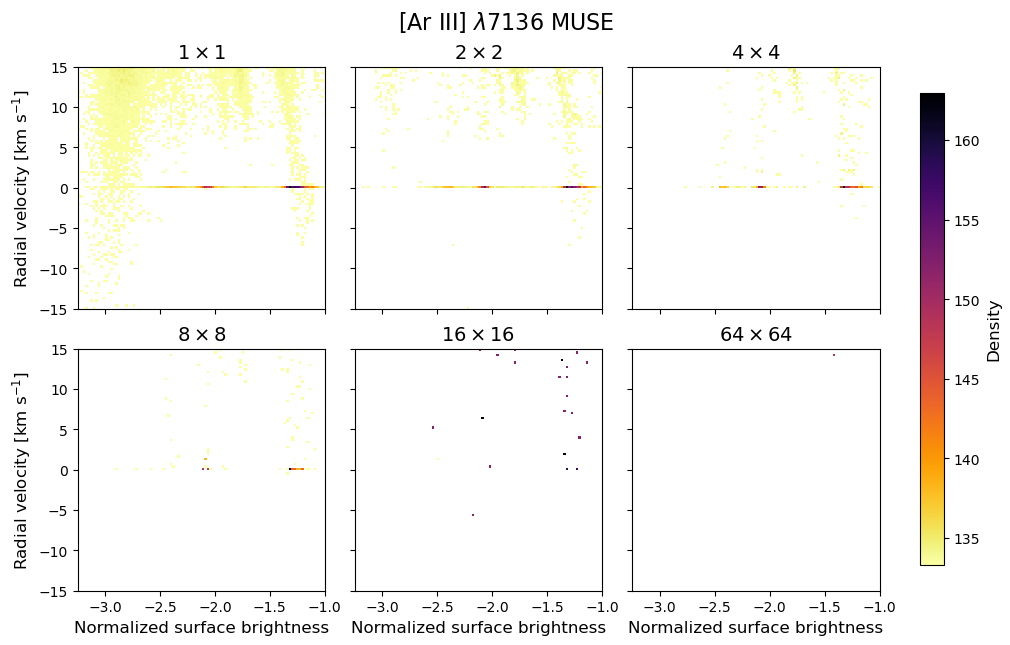

In [17]:
import numpy as np
import matplotlib.pyplot as plt

datasets = {
    0: ha_muse_bin0,
    1: ha_muse_bin1,
    2: ha_muse_bin2,
    3: ha_muse_bin3,
    4: ha_muse_bin4,
    5: ha_muse_bin5,
}

bin_labels = {
    0: r"$1\times1$",
    1: r"$2\times2$",
    2: r"$4\times4$",
    3: r"$8\times8$",
    4: r"$16\times16$",
    5: r"$64\times64$",
}

bin_order = [0, 1, 2, 3, 4, 5]

xrange = [-3.25, -1.0]
yrange = [-15, 15]

bins = 100

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(10, 6),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

axes = axes.flatten()

im = None

for ax, bin_id in zip(axes, bin_order):

    data = datasets[bin_id]

    SB = np.asarray(data["SB"])
    VV = np.asarray(data["VV"])

    mask = (
        np.isfinite(SB) &
        np.isfinite(VV) &
        (SB > 0)
    )

    SB_valid = SB[mask]
    VV_valid = VV[mask]

    SB_norm = SB_valid / (np.nanmedian(SB_valid) * 100)

    x = np.log10(SB_norm)
    y = VV_valid

    H, xedges, yedges = np.histogram2d(
        x,
        y,
        bins=bins,
        range=[xrange, yrange],
        density=True,
    )

    HH = np.where(H == 0, np.nan, H)

    im = ax.imshow(
        HH.T,
        origin="lower",
        aspect="auto",
        cmap="inferno_r",
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        interpolation="none",
    )

    ax.set_title(bin_labels[bin_id], fontsize=14)
    ax.set_xlim(xrange)
    ax.set_ylim(yrange)
    ax.grid(False)

for idx, ax in enumerate(axes):

    row = idx // 3
    col = idx % 3

    if col == 0:
        ax.set_ylabel(
            r"Radial velocity [km s$^{-1}$]",
            fontsize=12,
        )

    if row == 1:
        ax.set_xlabel(
            "Normalized surface brightness",
            fontsize=12,
        )

cbar = fig.colorbar(
    im,
    ax=axes,
    shrink=0.9,
    pad=0.03,
)

fig.suptitle(
    r"[Ar III] $\lambda7136$ MUSE",
    fontsize=16,
    y=1.05,
)

cbar.set_label("Density", fontsize=12)

plt.savefig(
    "SB_vs_radial_velocity_bins_grid_2x3_Ar.pdf",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

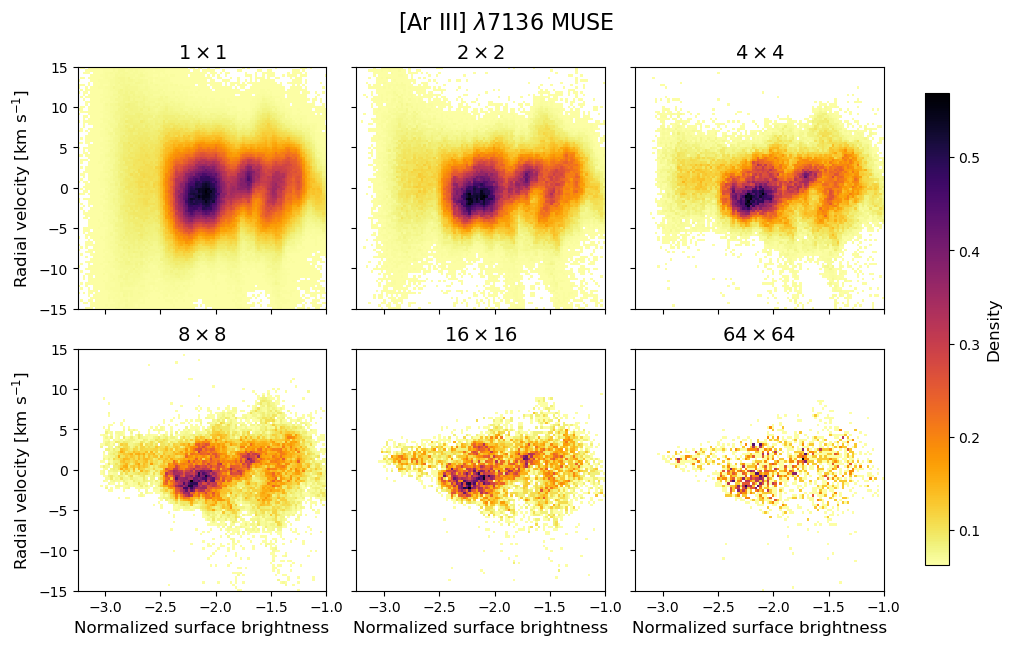

In [18]:
import numpy as np
import matplotlib.pyplot as plt

datasets = {
    0: ha_muse_bin0,
    1: ha_muse_bin1,
    2: ha_muse_bin2,
    3: ha_muse_bin3,
    4: ha_muse_bin4,
    5: ha_muse_bin5,
}

bin_labels = {
    0: r"$1\times1$",
    1: r"$2\times2$",
    2: r"$4\times4$",
    3: r"$8\times8$",
    4: r"$16\times16$",
    5: r"$64\times64$",
}

bin_order = [0, 1, 2, 3, 4, 5]

xrange = [-3.25, -1.0]
yrange = [-15, 15]

bins = 100

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(10, 6),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

axes = axes.flatten()

im = None

for ax, bin_id in zip(axes, bin_order):

    data = datasets[bin_id]

    SB = np.asarray(data["SB"])
    VV = np.asarray(data["VV"])

    mask = (
        np.isfinite(SB) &
        np.isfinite(VV) &
        (SB > 0)
    )

    SB_valid = SB[mask]
    VV_valid = VV[mask]

    SB_norm = SB_valid / (np.nanmedian(SB_valid) * 100)
    VV_cent = VV_valid-np.nanmean(VV_valid)

    x = np.log10(SB_norm)
    y = VV_cent

    H, xedges, yedges = np.histogram2d(
        x,
        y,
        bins=bins,
        range=[xrange, yrange],
        density=True,
    )

    HH = np.where(H == 0, np.nan, H)

    im = ax.imshow(
        HH.T,
        origin="lower",
        aspect="auto",
        cmap="inferno_r",
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        interpolation="none",
    )

    ax.set_title(bin_labels[bin_id], fontsize=14)
    ax.set_xlim(xrange)
    ax.set_ylim(yrange)
    ax.grid(False)

for idx, ax in enumerate(axes):

    row = idx // 3
    col = idx % 3

    if col == 0:
        ax.set_ylabel(
            r"Radial velocity [km s$^{-1}$]",
            fontsize=12,
        )

    if row == 1:
        ax.set_xlabel(
            "Normalized surface brightness",
            fontsize=12,
        )

cbar = fig.colorbar(
    im,
    ax=axes,
    shrink=0.9,
    pad=0.03,
)

fig.suptitle(
    r"[Ar III] $\lambda7136$ MUSE",
    fontsize=16,
    y=1.05,
)

cbar.set_label("Density", fontsize=12)

plt.savefig(
    "SB_vs_radial_velocity_bins_grid_2x3_Ar.pdf",
    dpi=600,
    bbox_inches="tight",
)

plt.show()